# Stage 09 — Homework Starter Notebook

In the lecture, we learned how to create engineered features. Now it’s your turn to apply those ideas to your own project data.

In [ ]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Example synthetic data (replace with your project dataset)
np.random.seed(0)
n = 100
df = pd.DataFrame({
    'income': np.random.normal(60000, 15000, n).astype(int),
    'monthly_spend': np.random.normal(2000, 600, n).astype(int),
    'credit_score': np.random.normal(680, 50, n).astype(int),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n),
    'default_flag': np.random.choice([0, 1], n, p=[0.8, 0.2]),
})
df.head()

,income,monthly_spend,credit_score,region,default_flag
0,86460,3129,661,East,0
1,66002,1191,668,North,0
2,74681,1237,734,West,0
3,93613,2581,712,South,1
4,88013,1296,712,East,1


## Engineered features — one is worked below; add at least two more

At least one of yours must encode a categorical column. `region` is the categorical
column here; the lecture shows three ways to encode it (one-hot, label, frequency).

In [2]:
# Worked example 1 of 3 — keep it, or swap in columns of your own.
df['spend_income_ratio'] = df['monthly_spend'] / df['income']
# Write the rationale in the markdown cell below.

### Rationale for Feature 1
This feature better captures spending behavior by finding the ratio of monthly_spend against income.

In [3]:
df['rolling_spend_mean'] = df['monthly_spend'].rolling(3).mean()

### Rationale for Feature 2
This feature improves the stability of monthly_spend data and reduces the impact of outliers.

In [4]:
df = pd.get_dummies(df, columns=['region'])

### Rationale for Feature 3
Region is one-hot encoded as it is a categorical feature; encoding allows region information to be numerically processed.

## Plot the correlation between each feature and the target variable

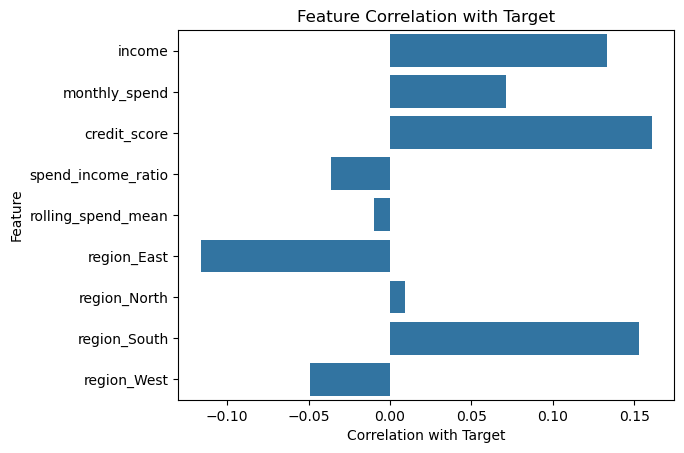

In [8]:
import seaborn as sns

target = 'default_flag'

corr = df.select_dtypes(['number', 'bool']).corr()[target].drop(target)

sns.barplot(x=corr.values, y=corr.index)
plt.xlabel('Correlation with Target')
plt.ylabel('Feature')
plt.title('Feature Correlation with Target')
plt.show()